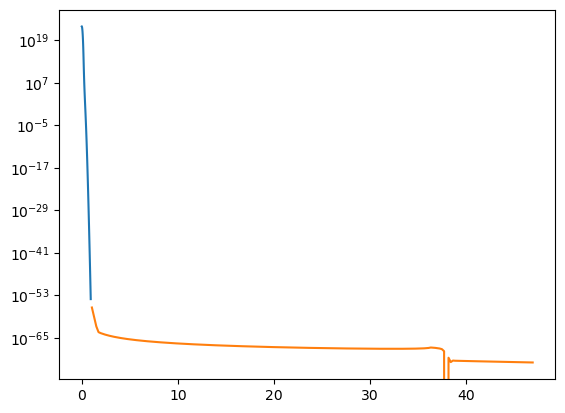

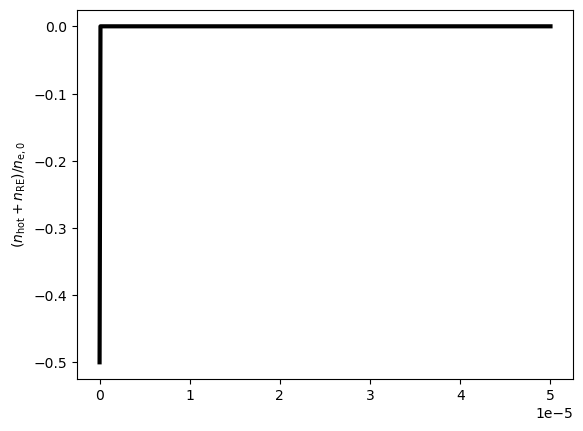

In [3]:
#!/usr/bin/env python3
#
# Plot full distribution function (f_hot + f_re)
# ######

import matplotlib.pyplot as plt
import numpy as np
import sys

sys.path.append('../../py')

from DREAM import *
from DREAM.DREAMOutput import DREAMOutput


do = DREAMOutput('output15.h5')

timeindex = -1
xiindex = -2
#plottype = '2d'
#plottype = 'avg'
plottype = 'last'

if plottype == '2d':
    fhot = do.eqsys.f_hot[timeindex,0,:]
    fre  = do.eqsys.f_re[timeindex,0,:]
elif plottype == 'avg':
    fhot = do.eqsys.f_hot.angleAveraged(t=timeindex, r=0)
    fre  = do.eqsys.f_re.angleAveraged(t=timeindex, r=0)
elif plottype == 'last':
    fhot = do.eqsys.f_hot[timeindex,0,xiindex,:]
    fre  = do.eqsys.f_re[timeindex,0,xiindex,:]


if plottype == '2d':
    levels = np.linspace(-66, 25, 20)
    plt.contourf(do.grid.hottail.p, do.grid.hottail.xi, np.log10(np.abs(fhot)), levels=levels)
    plt.contourf(do.grid.runaway.p, do.grid.runaway.xi, np.log10(np.abs(fre)), levels=levels)
    plt.xlim([0, 4])
    plt.ylim([-1,1])
else:
    plt.semilogy(do.grid.hottail.p, fhot)
    plt.semilogy(do.grid.runaway.p, fre)

plt.figure()

# Plot electron density evolution
nhot = do.eqsys.f_hot.density(r=0)
nre  = do.eqsys.f_re.density(r=0)
n0   = do.eqsys.n_cold[0,0]
plt.plot(do.grid.t, (nhot+nre-n0)/n0, 'k', linewidth=3)
plt.ylabel(r'$(n_{\rm hot} + n_{\rm RE}) / n_{\rm e,0}$')
#plt.semilogy(do.grid.t, nhot, '--', linewidth=2)
#plt.semilogy(do.grid.t, nre, '--', linewidth=2)
#plt.legend([r'$n_{\rm e}$', r'$n_{\rm hot}$', r'$n_{\rm RE}$'])

# Save the second figure
plt.savefig('electron_density_evolution.png')

# Show plots
plt.show()

# Close the DREAMOutput file
do.close()


读取并以树状结构的形式显示HDF5文件的内容结构，然后将该结构保存到一个文本文件中

In [4]:
import h5py

# Function to display HDF5 structure as a tree
def display_hdf5_tree(filename, output_file=None):
    """
    Display the structure of an HDF5 file as a tree
    
    Parameters:
    filename (str): Path to the HDF5 file
    output_file (str): Path to output file (optional)
    """
    def print_tree(name, obj, level, file_handle=None):
        line = "  " * level + f"- {name} ({type(obj).__name__})"
        if file_handle:
            file_handle.write(line + "\n")
        else:
            print(line)
        if isinstance(obj, h5py.Group):
            for key in obj.keys():
                print_tree(key, obj[key], level + 1, file_handle)
    
    try:
        with h5py.File(filename, 'r') as file:
            if output_file:
                with open(output_file, 'w') as f:
                    f.write(f"\nHDF5 File Structure: {filename}\n")
                    f.write("=" * 50 + "\n")
                    for key in file.keys():
                        print_tree(key, file[key], 0, f)
                print(f"HDF5 structure saved to {output_file}")
            else:
                print(f"\nHDF5 File Structure: {filename}")
                print("=" * 50)
                for key in file.keys():
                    print_tree(key, file[key], 0)
    except Exception as e:
        print(f"Error reading HDF5 file: {e}")

# Save the HDF5 file structure to a text file
display_hdf5_tree('output1.h5', 'hdf5_structure.txt')

HDF5 structure saved to hdf5_structure.txt


In [5]:
import h5py
import numpy as np

# Function to read and print E datasets
def print_e_datasets(filename):
    """
    Read and print the E datasets from the HDF5 file
    
    Parameters:
    filename (str): Path to the HDF5 file
    """
    try:
        with h5py.File(filename, 'r') as file:
            # Navigate to the fluid group
            fluid_group = file['other/fluid']
            
            # List of E datasets to read
            e_datasets = ['EDreic', 'Eceff', 'Ecfree', 'Ectot']
            
            print(f"Values from {filename} - other/fluid group:")
            print("=" * 60)
            
            for dataset_name in e_datasets:
                if dataset_name in fluid_group:
                    data = fluid_group[dataset_name][:]
                    print(f"\n{dataset_name}:")
                    print(f"  Shape: {data.shape}")
                    print(f"  Data type: {data.dtype}")
                    
                    # Print the actual values
                    if data.size <= 20:  # If small array, print all values
                        print(f"  Values: {data}")
                    else:  # If large array, print summary statistics
                        print(f"  Min: {np.min(data)}")
                        print(f"  Max: {np.max(data)}")
                        print(f"  Mean: {np.mean(data)}")
                        print(f"  First 5 values: {data.flat[:5]}")
                        print(f"  Last 5 values: {data.flat[-5:]}")
                else:
                    print(f"\n{dataset_name}: Dataset not found")
                    
    except Exception as e:
        print(f"Error reading HDF5 file: {e}")

# Print the E datasets
print_e_datasets('output1.h5')

Values from output1.h5 - other/fluid group:

EDreic:
  Shape: (500, 6)
  Data type: float64
  Min: 15.64586642162025
  Max: 15.645866421620292
  Mean: 15.645866421620283
  First 5 values: [15.64586642 15.64586642 15.64586642 15.64586642 15.64586642]
  Last 5 values: [15.64586642 15.64586642 15.64586642 15.64586642 15.64586642]

Eceff:
  Shape: (500, 6)
  Data type: float64
  Min: -0.12513819509317337
  Max: 0.1880564496684635
  Mean: 0.06567074638536244
  First 5 values: [ 0.06698222  0.07528985  0.08821657  0.10061759 -0.1251382 ]
  Last 5 values: [ 0.07528985  0.08821657  0.10061759 -0.1251382   0.18805645]

Ecfree:
  Shape: (500, 6)
  Data type: float64
  Min: 0.018878927944113617
  Max: 0.018878927944113676
  Mean: 0.01887892794411366
  First 5 values: [0.01887893 0.01887893 0.01887893 0.01887893 0.01887893]
  Last 5 values: [0.01887893 0.01887893 0.01887893 0.01887893 0.01887893]

Ectot:
  Shape: (500, 6)
  Data type: float64
  Min: 0.018878927944113673
  Max: 0.018878927944113676

查看径向网格点数量

In [6]:
import h5py

# Function to get the number of radial grid points
def get_radial_grid_points(filename):
    """
    Get the number of radial grid points from the HDF5 file.
    
    Parameters:
    filename (str): Path to the HDF5 file (e.g., 'output1.h5')
    
    Returns:
    int: Number of radial grid points, or None if not found.
    """
    try:
        with h5py.File(filename, 'r') as file:
            # Common paths for radial grid in DREAM output
            possible_paths = ['grid/r', 'grid/r_f', 'r', 'r_f'] # r_f might be the face-centered grid
            
            r_data = None
            for path in possible_paths:
                if path in file:
                    r_data = file[path][:]
                    break
            
            if r_data is not None:
                num_points = len(r_data)
                print(f"Radial grid data found at '{path}'")
                print(f"Radial grid points (coordinates): {r_data}")
                print(f"Number of radial grid points: {num_points}")
                return num_points
            else:
                print("Radial grid data not found in common locations.")
                # List keys at root level to help identify the correct path
                print("Root level keys in the file:")
                for key in file.keys():
                    print(f"  - {key}")
                # If 'grid' exists, list its keys too
                if 'grid' in file:
                    print("Keys under 'grid':")
                    for key in file['grid'].keys():
                        print(f"  - {key}")
                return None
                
    except Exception as e:
        print(f"Error reading HDF5 file: {e}")
        return None

# --- Usage ---
# Replace 'output1.h5' with your actual file name if different
filename = 'output1.h5'
num_radial_points = get_radial_grid_points(filename)

if num_radial_points is not None:
    print(f"\nThe number of radial grid points is: {num_radial_points}")
else:
    print("\nCould not determine the number of radial grid points.")

Radial grid data found at 'grid/r'
Radial grid points (coordinates): [0.625 0.675 0.725 0.775 0.825 0.875]
Number of radial grid points: 6

The number of radial grid points is: 6
